In [1]:
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
import re
import numpy as np
from scipy import stats
import pickle
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

In [2]:
# we're going to revise our approach. we have tabix filtered the mpac preds with the 250bp promoters and full IDs - not just HGNC
# we are going to call everything that we can for those promoters.
# similarly, for the promoterAI promoters we will capture as many promoter as possible with perfect overlap (all 250bp)
# for comparison across the 3 groups (we haven't forgotten about you PARM) we will take the subset present in all 3 groups
# i added annotations with VcfAnnotateFromBed in order to more easily remove overlapping promoters

In [3]:
# define function to convert predictions to final df
def vcf2df (pred_df):
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    gene_id = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df[7]):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
        # add annotated gene name
        #gene_id.append(all_preds[-1].split('=')[-1])
    
    df = pd.DataFrame({'chrom' : pred_df[0],
                       'pos' : pred_df[1],
                       'id' : pred_df[2],
                       'ref' : pred_df[3],
                       'alt' : pred_df[4],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew,
                       'gene_id' : [i.split('..')[0].split('_')[0] for i in pred_df[2]],
                       'transcript_id' : [i.split('..')[0].split('_')[1] for i in pred_df[2]],
                       'hgnc_id' : [i.split('..')[0].split('_')[-1] for i in pred_df[2]]})
    return df

In [4]:
# open tabix filtered (tabix_filter_mpac_preds.sh) predictions and reformat for downstream analyses
all_tabix_mpac_preds = vcf2df(pd.read_csv('../mpac/processed_data/all.mpac.preds.tabix.filtered.gencode.250bp.full.ID.112125.vcf', sep = '\t', header = None))

100%|██████████| 13532340/13532340 [01:30<00:00, 149524.72it/s]


In [5]:
# open exon filtering bed file - to prevent double inclusion of overlapping intevals
filtered_250_bed = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.exon.filtered.bed', sep = '\t', header = None)
filtered_250_bed.loc[:, 'gene_id'] = [i.split('_')[0] for i in filtered_250_bed[3]]

In [6]:
# filter all tabix filtered preds for those in the BED file
twoFifty_mpac_preds = all_tabix_mpac_preds[all_tabix_mpac_preds['gene_id'].isin(filtered_250_bed['gene_id'].tolist())].drop_duplicates()
# len(final_mpac_preds['gene_id'].unique()) - equals 17985, same as the number in the original BED file

In [7]:
# add the bed file intervals to df to subset for only positions in the desired promoter intervals
merged = twoFifty_mpac_preds.merge(
    filtered_250_bed, 
    on='gene_id',
    how='left',
)

In [8]:
# filter for only the desired promoter intervals
final_mpac_preds = merged[
    (merged['pos'] > merged[1]) & 
    (merged['pos'] <= merged[2])
].drop(columns=[1,2,0,4,5,3])

In [9]:
final_mpac_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,gene_id,transcript_id,hgnc_id
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,-0.005339,0.558187,0.547707,-0.010479,ENSG00000186092.7,ENST00000641515.2,OR4F5
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,-0.004132,0.558187,0.539187,-0.019000,ENSG00000186092.7,ENST00000641515.2,OR4F5
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,-0.022653,0.558187,0.530182,-0.028004,ENSG00000186092.7,ENST00000641515.2,OR4F5
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,0.059047,0.538484,0.640290,0.101806,ENSG00000186092.7,ENST00000641515.2,OR4F5
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,C,0.287499,0.300818,0.013319,0.352586,0.341317,-0.011269,0.538484,0.505176,-0.033308,ENSG00000186092.7,ENST00000641515.2,OR4F5


In [10]:
# add an ID (chr:pos:ref:alt) for merging predictions with PARM and promoterAI
final_mpac_preds.loc[:,'merge_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(final_mpac_preds['chrom'],
                                                                                                              final_mpac_preds['pos'],
                                                                                                              final_mpac_preds['ref'],
                                                                                                              final_mpac_preds['alt'])]

In [ ]:
# let's add some annotations for easier plotting/merging/comparing to other models
# add the mean ref activity
mean_activity = final_mpac_preds.filter(['k562_ref_pred', 'hepg2_ref_pred', 'sknsh_ref_pred', 'gene_id']).groupby('gene_id').mean()
# make dictionaries for adding reference activity to main DF
# k562
k562_mean_act = dict(zip(mean_activity.index, mean_activity['k562_ref_pred']))
hepg2_mean_act = dict(zip(mean_activity.index, mean_activity['hepg2_ref_pred']))
sknsh_mean_act = dict(zip(mean_activity.index, mean_activity['sknsh_ref_pred']))

In [ ]:
# mean reference activity to main DF
final_mpac_preds.loc[:, 'k562_mean_ref'] = [k562_mean_act.get(i) for i in final_mpac_preds['gene_id']]
final_mpac_preds.loc[:, 'hepg2_mean_ref'] = [hepg2_mean_act.get(i) for i in final_mpac_preds['gene_id']]
final_mpac_preds.loc[:, 'sknsh_mean_ref'] = [sknsh_mean_act.get(i) for i in final_mpac_preds['gene_id']]

In [ ]:
# add active or emVar annotations to DF
# active
final_mpac_preds.loc[:, 'k562_mean_active'] = [1 if i >= 1 else 0 for i in final_mpac_preds['k562_mean_ref']]
final_mpac_preds.loc[:, 'hepg2_mean_active'] = [1 if i >= 1 else 0 for i in final_mpac_preds['hepg2_mean_ref']]
final_mpac_preds.loc[:, 'sknsh_mean_active'] = [1 if i >= 1 else 0 for i in final_mpac_preds['sknsh_mean_ref']]
# add an active 'any' feature
final_mpac_preds.loc[:, 'mean_active_any'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(final_mpac_preds['k562_mean_active'],
                                                                                            final_mpac_preds['hepg2_mean_active'],
                                                                                            final_mpac_preds['sknsh_mean_active'])]
# emVar
final_mpac_preds.loc[:, 'k562_emVar'] = [1 if abs(i) > 0.5 else 0 for i in final_mpac_preds['k562_skew_pred']]
final_mpac_preds.loc[:, 'hepg2_emVar'] = [1 if abs(i) > 0.5 else 0 for i in final_mpac_preds['hepg2_skew_pred']]
final_mpac_preds.loc[:, 'sknsh_emVar'] = [1 if abs(i) > 0.5 else 0 for i in final_mpac_preds['sknsh_skew_pred']]
# add an emVar 'any' feature
final_mpac_preds.loc[:, 'emVar_any'] = [1 if sum([k,h,s]) > 0 else 0 for k,h,s in zip(final_mpac_preds['k562_emVar'],
                                                                                      final_mpac_preds['hepg2_emVar'],
                                                                                      final_mpac_preds['sknsh_emVar'])]
final_mpac_preds.loc[:, 'emVar_all'] = [1 if sum([k,h,s]) == 3 else 0 for k,h,s in zip(final_mpac_preds['k562_emVar'],
                                                                                      final_mpac_preds['hepg2_emVar'],
                                                                                      final_mpac_preds['sknsh_emVar'])]                                                                 

In [ ]:
# open TPMs from Stephen for adding RNA expression to DF
rna_expression = pd.read_csv('../raw_data/rna_celline_filtered.tsv', sep = '\t')
# make dictionaries for adding TPMs to DF
k562_rna_expression = dict(zip(rna_expression[rna_expression['Cell line'] == 'K-562']['Gene'],
                               rna_expression[rna_expression['Cell line'] == 'K-562']['TPM']))
hepg2_rna_expression = dict(zip(rna_expression[rna_expression['Cell line'] == 'Hep-G2']['Gene'],
                               rna_expression[rna_expression['Cell line'] == 'Hep-G2']['TPM']))
sknsh_rna_expression = dict(zip(rna_expression[rna_expression['Cell line'] == 'SK-N-SH']['Gene'],
                                rna_expression[rna_expression['Cell line'] == 'SK-N-SH']['TPM']))

In [ ]:
# add TPMs to DF
final_mpac_preds.loc[:, 'k562_rna_tpm'] = [k562_rna_expression.get(i.split('.')[0]) for i in final_mpac_preds['gene_id']]
final_mpac_preds.loc[:, 'hepg2_rna_tpm'] = [hepg2_rna_expression.get(i.split('.')[0]) for i in final_mpac_preds['gene_id']]
final_mpac_preds.loc[:, 'sknsh_rna_tpm'] = [sknsh_rna_expression.get(i.split('.')[0]) for i in final_mpac_preds['gene_id']]

In [ ]:
final_mpac_preds.to_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.tsv', sep = '\t', index = False)

There are 17958 unique gene IDs in the full predictions
There are 12153 non-overlapping promoters with complete sat mut predictions


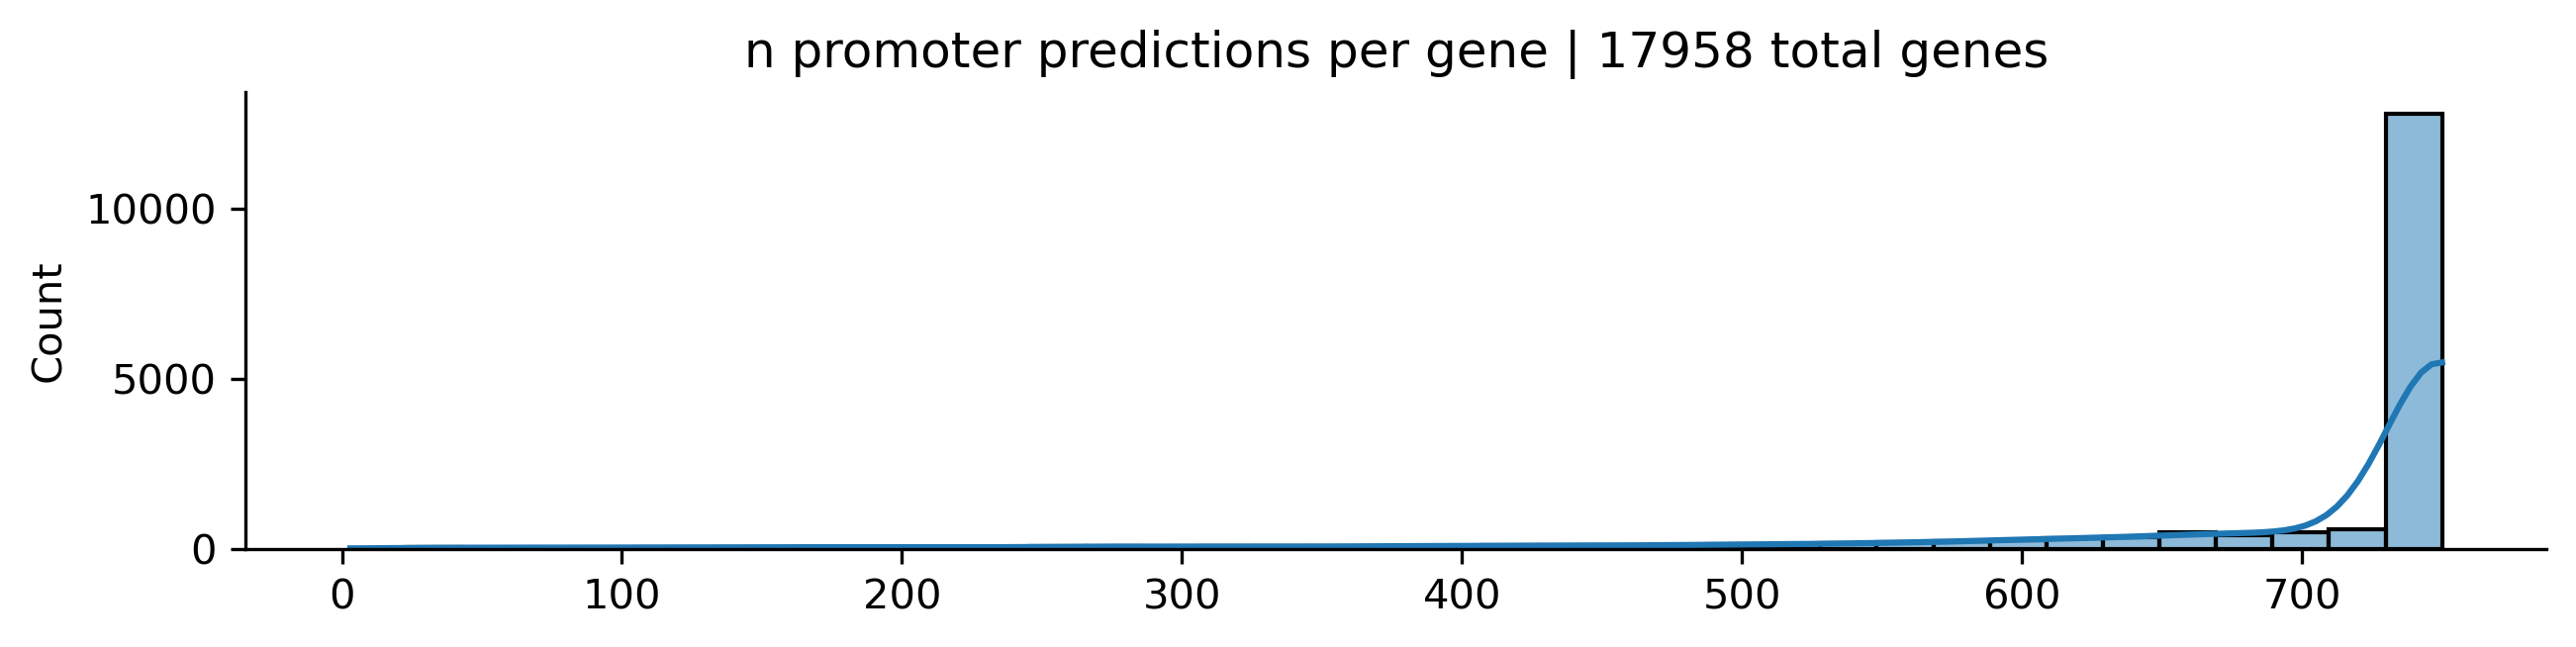

In [ ]:
# get a summary of predictions
print(f'There are {len(final_mpac_preds['gene_id'].unique())} unique gene IDs in the full predictions')
# make a counter of gene_ids
gene_id_count = Counter(final_mpac_preds['gene_id'])
# plot the distributions of predictions per ID
mpl.figure(dpi=300, figsize=(10,2))
sns.histplot(gene_id_count.values(), binwidth=20, kde=True, legend=False)
sns.despine()
mpl.title(f'n promoter predictions per gene | {len(final_mpac_preds['gene_id'].unique())} total genes')
# as expected, the majority are 750bp total, however, there are some that have overlapping promoters that are > 750 predictions, let's get the 250bp promoters only
# and do an annotation check that there aren't overlapping intervals that happen to be 750 bp
twoFifty_single_genes = [i for i in gene_id_count.keys() if gene_id_count.get(i) == 750 and len(i.split(':')) == 1]
print(f'There are {len(twoFifty_single_genes)} non-overlapping promoters with complete sat mut predictions')

In [ ]:
# all promoters are a max of 250bp as they should be. we have predictions for 17,958 such 250bp promoter intervals.
# let's re-call the seqlets.

In [ ]:
# define our function for generating tensors
def predictions_to_tensors_multi_cell(df):
    """
    Converts a DataFrame with multi-cell type saturation mutagenesis
    predictions into a nested dictionary of tensors.

    Args:
        df (pd.DataFrame):
            DataFrame with columns like 'id', 'pos', 'ref', 'alt',
            and cell-specific columns such as 'k562_skew_pred'.

    Returns:
        dict: A nested dictionary in the format {cell_type: {id: tensor}},
              where each tensor is a (4, sequence_length) PyTorch tensor.
    """
    # make a list for storing misfitting genes #
    misfit_genes = []
    # Dynamically find cell types from column names (e.g., 'k562_skew_pred')
    cell_types = sorted(list(set([col.split('_')[0] for col in df.columns if '_skew_pred' in col])))
    print(f"Detected cell types: {', '.join(cell_types)}")
    
    # A mapping from DNA base to the tensor row index
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    # Initialize the nested dictionary structure
    tensor_dict = {cell: {} for cell in cell_types}
    
    # Group by the gene/enhancer ID
    for gene_id, gene_df in tqdm(df.groupby('gene_id'), desc="Converting IDs to Tensors"):
        
        # Temp dict to hold lists of position vectors for each cell type
        position_vectors_by_cell = {cell: [] for cell in cell_types}

        # Within each gene's data, group by position
        for pos, pos_df in gene_df.groupby('pos'):
            
            # Create a 4-element vector for each cell type for this position
            score_vectors = {cell: [0.0] * 4 for cell in cell_types}
            
            # Fill in the scores for the alternate bases for each cell type
            for _, row in pos_df.iterrows():
                alt_base_index = base_map[row['alt'].upper()]
                for cell in cell_types:
                    score_col = f"{cell}_skew_pred"
                    score_vectors[cell][alt_base_index] = row[score_col]
            
            # Append the completed vector for each cell type
            for cell in cell_types:
                position_vectors_by_cell[cell].append(score_vectors[cell])
                
        # After processing all positions, create the final tensor for each cell type
        for cell in cell_types:
            final_tensor = torch.tensor(position_vectors_by_cell[cell], dtype=torch.float32).T
            # check the length of the tensor
            if final_tensor.shape[-1] == 250:
                tensor_dict[cell][gene_id] = final_tensor
            else:
                misfit_genes.append(gene_id)
    return tensor_dict, misfit_genes

In [ ]:
# added padding so we can generate seqlets for non-full length promoters
# define our function for generating tensors
def predictions_to_tensors_multi_cell(df, target_length=250):
    """
    Converts a DataFrame with multi-cell type saturation mutagenesis
    predictions into a nested dictionary of tensors.
    Args:
        df (pd.DataFrame):
            DataFrame with columns like 'id', 'pos', 'ref', 'alt',
            and cell-specific columns such as 'k562_skew_pred'.
        target_length (int):
            Target sequence length. Shorter sequences will be zero-padded.
    Returns:
        dict: A nested dictionary in the format {cell_type: {id: tensor}},
              where each tensor is a (4, target_length) PyTorch tensor.
    """
    # make a list for storing misfitting genes #
    misfit_genes = []
    
    # Dynamically find cell types from column names (e.g., 'k562_skew_pred')
    cell_types = sorted(list(set([col.split('_')[0] for col in df.columns if '_skew_pred' in col])))
    print(f"Detected cell types: {', '.join(cell_types)}")
    
    # A mapping from DNA base to the tensor row index
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    # Initialize the nested dictionary structure
    tensor_dict = {cell: {} for cell in cell_types}
    
    # Group by the gene/enhancer ID
    for gene_id, gene_df in tqdm(df.groupby('gene_id'), desc="Converting IDs to Tensors"):
        # Temp dict to hold lists of position vectors for each cell type
        position_vectors_by_cell = {cell: [] for cell in cell_types}
        
        # Within each gene's data, group by position
        for pos, pos_df in gene_df.groupby('pos'):
            # Create a 4-element vector for each cell type for this position
            score_vectors = {cell: [0.0] * 4 for cell in cell_types}
            
            # Fill in the scores for the alternate bases for each cell type
            for _, row in pos_df.iterrows():
                alt_base_index = base_map[row['alt'].upper()]
                for cell in cell_types:
                    score_col = f"{cell}_skew_pred"
                    score_vectors[cell][alt_base_index] = row[score_col]
            
            # Append the completed vector for each cell type
            for cell in cell_types:
                position_vectors_by_cell[cell].append(score_vectors[cell])
        
        # After processing all positions, create the final tensor for each cell type
        for cell in cell_types:
            final_tensor = torch.tensor(position_vectors_by_cell[cell], dtype=torch.float32).T
            
            # Check the length of the tensor
            current_length = final_tensor.shape[-1]
            
            if current_length == target_length:
                tensor_dict[cell][gene_id] = final_tensor
            elif current_length < target_length:
                # Pad with zeros to reach target_length
                padding_size = target_length - current_length
                padding = torch.zeros((4, padding_size), dtype=torch.float32)
                padded_tensor = torch.cat([final_tensor, padding], dim=1)
                tensor_dict[cell][gene_id] = padded_tensor
            else:
                # Longer than expected - mark as misfit
                misfit_genes.append(gene_id)
    
    return tensor_dict, misfit_genes

In [ ]:
# generate raw tensors for each cell type eg for A : [o, skew, skew, skew], etc.
mpac_promoter_rawTensors, misfit_tensor_ids = predictions_to_tensors_multi_cell(final_mpac_preds)

Detected cell types: hepg2, k562, sknsh


Converting IDs to Tensors: 100%|██████████| 17958/17958 [17:12<00:00, 17.39it/s]


In [ ]:
# mismatches are the same in all cell types, hence the triplicate
pd.Series(misfit_tensor_ids).unique()
# no missing IDs, as expected

array([], dtype=object)

In [ ]:
# store the dictionary keys (promoter names) as a list for annotating seqlets, oneHots, etc.
promoter_list = list(mpac_promoter_rawTensors['k562'].keys())
# stack the tensors for each cell type
# k562
k_rawStacked = torch.stack([mpac_promoter_rawTensors['k562'][i] for i in promoter_list])
# hepg2
h_rawStacked = torch.stack([mpac_promoter_rawTensors['hepg2'][i] for i in promoter_list])
# sknsh
s_rawStacked = torch.stack([mpac_promoter_rawTensors['sknsh'][i] for i in promoter_list])

In [ ]:
# define funtion for returning seqlets, oneHot encoded tensors, and plotLogo tensors for each cell type
def tensors4tangermeme (stacked_raw_tensors, gene_list):
    # make empty dictionaries for each type of seqlet to return
    seqlet_dict = {}
    plotLogo_dict = {}
    oneHot_dict = {}

    # iterate through stacked tensors and modify for each type
    for index, promoter in enumerate(gene_list):
        # pull the tensor to modify
        raw_tensor = stacked_raw_tensors[index]
        # make oneHot tensor
        oneHot_tensor = 1 * (raw_tensor == 0)
        # make seqlet tensor
        seqlet_tensor = (-1 * (raw_tensor.sum(dim=0))) / 3
        # make plot logo tensor
        plotLogo_tensor = oneHot_tensor * seqlet_tensor
        # update dictionaries
        seqlet_dict[promoter] = seqlet_tensor
        plotLogo_dict[promoter] = plotLogo_tensor
        oneHot_dict[promoter] = oneHot_tensor
    return seqlet_dict, plotLogo_dict, oneHot_dict;

In [ ]:
# return tensors for each cell type
# k562
k_seqlet_dict, k_plotLogo_dict, k_oneHot_dict = tensors4tangermeme(k_rawStacked, promoter_list)
# hepg2
h_seqlet_dict, h_plotLogo_dict, h_oneHot_dict = tensors4tangermeme(h_rawStacked, promoter_list)
# sknsh
s_seqlet_dict, s_plotLogo_dict, s_oneHot_dict = tensors4tangermeme(s_rawStacked, promoter_list)

In [ ]:
# define a function for stacking each seqlet dictionary for each cell type
def stack_tensors (seqlet_dict, plotLogo_dict, oneHot_dict, promoters):
    # stack seqlets
    seqlet_stack = torch.stack([seqlet_dict[promoter] for promoter in promoters])
    # stack plotLogos
    plotLogo_stack = torch.stack([plotLogo_dict[promoter] for promoter in promoters])
    # stack oneHots
    oneHot_stack = torch.stack([oneHot_dict[promoter] for promoter in promoters])
    return seqlet_stack, plotLogo_stack, oneHot_stack;

In [ ]:
# stack all tensors for calling seqlets, annotating them, etc.
# k562
k_stackedSeqlets, k_stackedPlotLogos, k_stackedOneHots = stack_tensors(k_seqlet_dict, k_plotLogo_dict, k_oneHot_dict, promoter_list)
# hepg2
h_stackedSeqlets, h_stackedPlotLogos, h_stackedOneHots = stack_tensors(h_seqlet_dict, h_plotLogo_dict, h_oneHot_dict, promoter_list)
# sknsh
s_stacked_Seqlets, s_stackedPlotLogos, s_stackedOneHots = stack_tensors(s_seqlet_dict, s_plotLogo_dict, s_oneHot_dict, promoter_list)

In [ ]:
# call seqlets for each cell type
# k562
k_seqlet_calls = recursive_seqlets(k_stackedSeqlets, threshold=0.01)
# hepg2
h_seqlet_calls = recursive_seqlets(h_stackedSeqlets, threshold=0.01)
# sknsh
s_seqlet_calls = recursive_seqlets(s_stacked_Seqlets, threshold=0.01)

In [ ]:
# define a function for annotating seqlets
def ann_seqlets (path2pwms, motif_database, stacked_oneHots, seqlet_calls, promoters):
    # store motif info as a variable
    motif_path = f'{path2pwms}/{motif_database}'
    # open pwms
    motifs = read_meme(motif_path)
    motif_names = list(motifs.keys())
    # run annotate seqlets
    motif_idxs, motif_pvals = annotate_seqlets(stacked_oneHots, seqlet_calls, motif_path)
    # make a dictionary of indices and gene names for annotating promoters
    promoter_idx_dict = dict(zip([promoters.index(i) for i in promoters], promoters))
    # make copies of the seqlet DFs for annotating with promoter names and tf names
    # tf for plotLogos
    tf_ann_seqlets = seqlet_calls.copy()
    tf_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs] # use this one with plotLogos
    # tf + promoter id
    full_ann_seqlets = seqlet_calls.copy()
    # add enhancer ids
    full_ann_seqlets.loc[:, 'promoter_id'] = [promoter_idx_dict.get(i) for i in full_ann_seqlets['example_idx']]
    # add matching motif
    full_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs]
    # add pval of match
    full_ann_seqlets.loc[:,'pval'] = [float(i[0]) for i in motif_pvals]
    return tf_ann_seqlets, full_ann_seqlets;

In [ ]:
# annotate seqlets for each cell type
# k562
k_tf_ann_seqlets, k_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        k_stackedOneHots,
                                                        k_seqlet_calls,
                                                        promoter_list)
# hepg2
h_tf_ann_seqlets, h_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        h_stackedOneHots,
                                                        h_seqlet_calls,
                                                        promoter_list)
# sknsh
s_tf_ann_seqlets, s_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        s_stackedOneHots,
                                                        s_seqlet_calls,
                                                        promoter_list)

/tmp/ipykernel_1850548/3739010979.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'GFI1_HUMAN.H11MO.0.C', 'NRF1_HUMAN.H11MO.0.A', 'NRF1_HUMAN.H11MO.0.A', 'WT1_HUMAN.H11MO.0.C', 'GFI1B_HUMAN.H11MO.0.A', 'TGIF1_HUMAN.H11MO.0.A', 'NRF1_HUMAN.H11MO.0.A', 'GFI1_HUMAN.H11MO.0.C', 'KAISO_HUMAN.H11MO.0.A', 'HIC1_HUMAN.H11MO.0.C', 'REST_HUMAN.H11MO.0.A', 'ZN250_HUMAN.H11MO.0.C', 'NRF1_HUMAN.H11MO.0.A', 'ELK1_HUMAN.H11MO.0.B', 'SP1_HUMAN.H11MO.0.A', 'KAISO_HUMAN.H11MO.0.A', 'NRF1_HUMAN.H11MO.0.A', 'KLF9_HUMAN.H11MO.0.C', 'KAISO_HUMAN.H11MO.0.A', 'BACH2_HUMAN.H11MO.0.A', 'ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'NRF1_HUMAN.H11MO.0.A', 'PKNX1_HUMAN.H11MO.0.B', 'GFI1_HUMAN.H11MO.0.C', 'KLF12_HUMAN.H11MO.0.C', 'CREM_HUMAN.H11MO.0.C', 'CREM_HUMAN.H11MO.0.C', 'TEAD1_HUMAN.H11MO.0.A', 'KLF12_HUMAN.H11MO.0.C', 'MECP2_HUMAN.H1

In [ ]:
# save annotated seqlets and things needed for plotting to disk
# k562
k_seqlet_calls.to_csv('../mpac/processed_data/mpac_k562_seqlet_calls.tsv', sep = '\t', index = False)
k_full_ann_seqlets.to_csv('../mpac/processed_data/mpac_k562_full_ann_seqlets.tsv', sep = '\t', index = False)
with open('../mpac/processed_data/mpac_k562_plotLogo_dict.pkl', 'wb') as f: # Open in write binary mode ('wb')
    pickle.dump(k_plotLogo_dict, f)
# hepg2
h_seqlet_calls.to_csv('../mpac/processed_data/mpac_hepg2_seqlet_calls.tsv', sep = '\t', index = False)
h_full_ann_seqlets.to_csv('../mpac/processed_data/mpac_hepg2_full_ann_seqlets.tsv', sep = '\t', index = False)
with open('../mpac/processed_data/mpac_hepg2_plotLogo_dict.pkl', 'wb') as f: # Open in write binary mode ('wb')
    pickle.dump(h_plotLogo_dict, f)
# sknsh
s_seqlet_calls.to_csv('../mpac/processed_data/mpac_sknsh_seqlet_calls.tsv', sep = '\t', index = False)
s_full_ann_seqlets.to_csv('../mpac/processed_data/mpac_sknsh_full_ann_seqlets.tsv', sep = '\t', index = False)
with open('../mpac/processed_data/mpac_sknsh_plotLogo_dict.pkl', 'wb') as f: # Open in write binary mode ('wb')
    pickle.dump(s_plotLogo_dict, f)

In [ ]:
def plot_specific_logos (seqlets,
                         annotated_seqlets,
                         promoter_id,
                         plotLogo_tensors,
                         cell):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # make a dictionary for annotating seqlets calls with promoters
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    if len(pro_seqlets) > 0:
        mpl.figure(figsize=(20,1), dpi=300)
        ax = mpl.subplot(111)
        plot_logo(plotLogo_tensors[promoter_id], annotations=pro_ann, score_key='attribution')
        for idx, row in pro_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.15, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'{cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[promoter_id])
        mpl.title(f'{cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()

In [ ]:
# define the optimized function for converting seqlets to a bed file
def seqlets2bed_optimized(full_preds,
                          full_ann_seqlets):
    """
    Converts seqlet predictions to a BED DataFrame using vectorized operations.
    """
    # 1. Get min position for each enhancer. This is already efficient.
    # The result is a Series where the index is 'id' and values are the min 'pos'.
    promoter_min_pos = full_preds.groupby('gene_id')['pos'].min()
    promoter_chrom = full_preds.groupby('gene_id')['chrom'].min()
    #promoter_attrib = 
    # Get the seqlets DataFrame from your dictionary
    seqlets = full_ann_seqlets.copy() # Use .copy() to avoid SettingWithCopyWarning

    # 2. Map the enhancer start positions to each seqlet.
    # This single vectorized operation replaces your entire outer 'for enh...' loop.
    seqlets['promoter_start'] = seqlets['promoter_id'].map(promoter_min_pos)
    seqlets['chrom'] = seqlets['promoter_id'].map(promoter_chrom)
    # Drop any seqlets whose enhancer_id was not found in 'full_preds'
    seqlets.dropna(subset=['promoter_start'], inplace=True)
    
    # Ensure the new column is an integer type for calculations
    seqlets['promoter_start'] = seqlets['promoter_start'].astype(int)

    # 3. Calculate BED coordinates and IDs vectorially.
    # These three lines replace your inner loop and all list appends.
    bed_start = seqlets['promoter_start'] + seqlets['start'] - 1 # Convert to 0-based
    bed_end = seqlets['promoter_start'] + seqlets['end']
    bed_id = seqlets['example_idx'].astype(str) + '_' + seqlets['promoter_id']
    # append attribution to id
    bed_id = [f'{i}_{str(j)}' for i, j in zip(bed_id, seqlets['attribution'].tolist())]
    chromosome = seqlets['chrom']
    # 4. Assemble the final DataFrame in one step.
    bed2return = pd.DataFrame({
        'chrom': chromosome,
        'start': bed_start,
        'end': bed_end,
        'id': bed_id
    }).sort_values(by=['chrom', 'start'])
    
    return bed2return

In [ ]:
# generate BED files for each cell type
# k562
k_seqlet_bed = seqlets2bed_optimized(final_mpac_preds, k_full_ann_seqlets)
# hepg2
h_seqlet_bed = seqlets2bed_optimized(final_mpac_preds, h_full_ann_seqlets)
# sknsh
s_seqlet_bed = seqlets2bed_optimized(final_mpac_preds, s_full_ann_seqlets)

In [ ]:
# # save BED files to disk
# k562
k_seqlet_bed.to_csv('../processed_data/bed_files/k562_mpac_annotated_seqlets_01_112225.bed', sep = '\t', index = False, header = None)
# hepg2
h_seqlet_bed.to_csv('../processed_data/bed_files/hepg2_mpac_annotated_seqlets_01_112225.bed', sep = '\t', index = False, header = None)
# sknsh
s_seqlet_bed.to_csv('../processed_data/bed_files/sknsh_mpac_annotated_seqlets_01_112225.bed', sep = '\t', index = False, header = None)

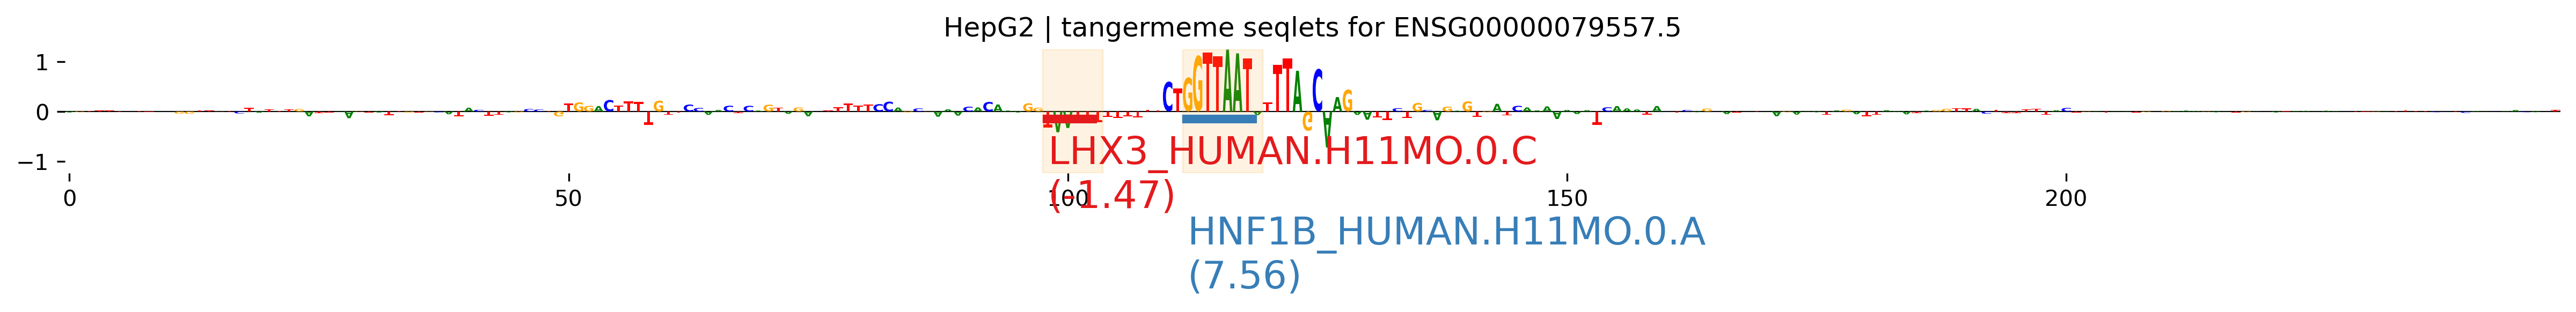

In [32]:
plot_specific_logos(h_seqlet_calls,
                    h_full_ann_seqlets,
                    'ENSG00000079557.5', #AFM
                    h_plotLogo_dict,
                    'HepG2')

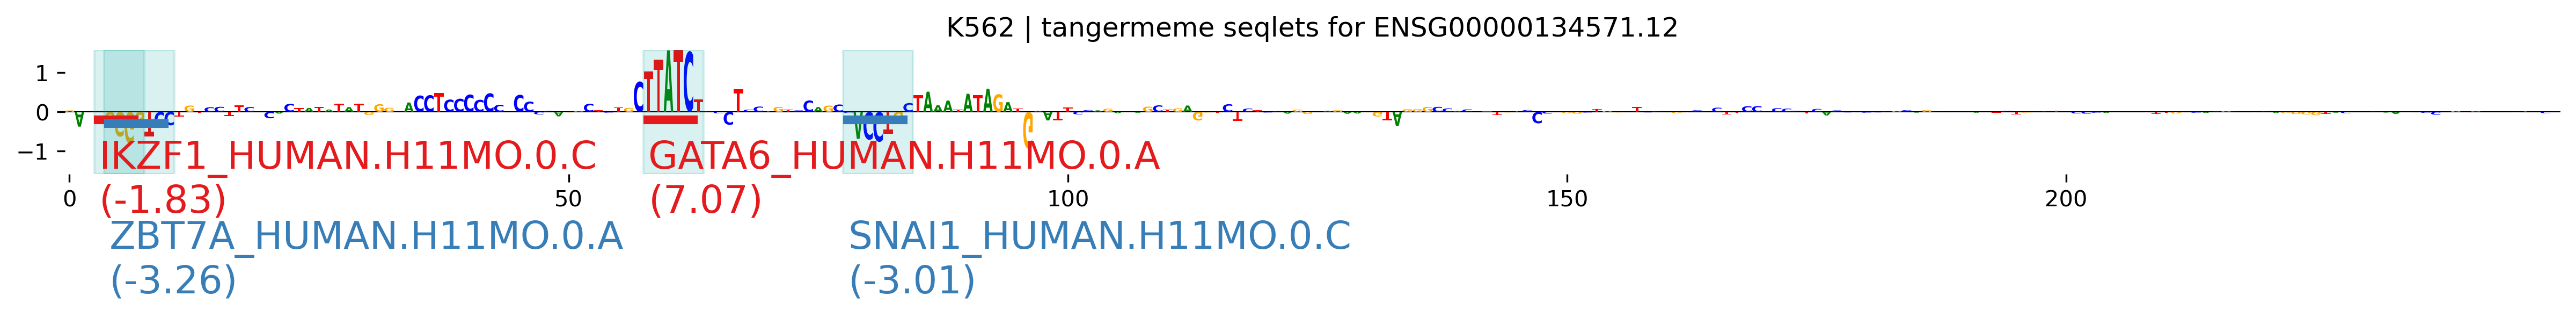

In [64]:
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'ENSG00000134571.12', #MYBPC3
                    k_plotLogo_dict,
                    'K562')

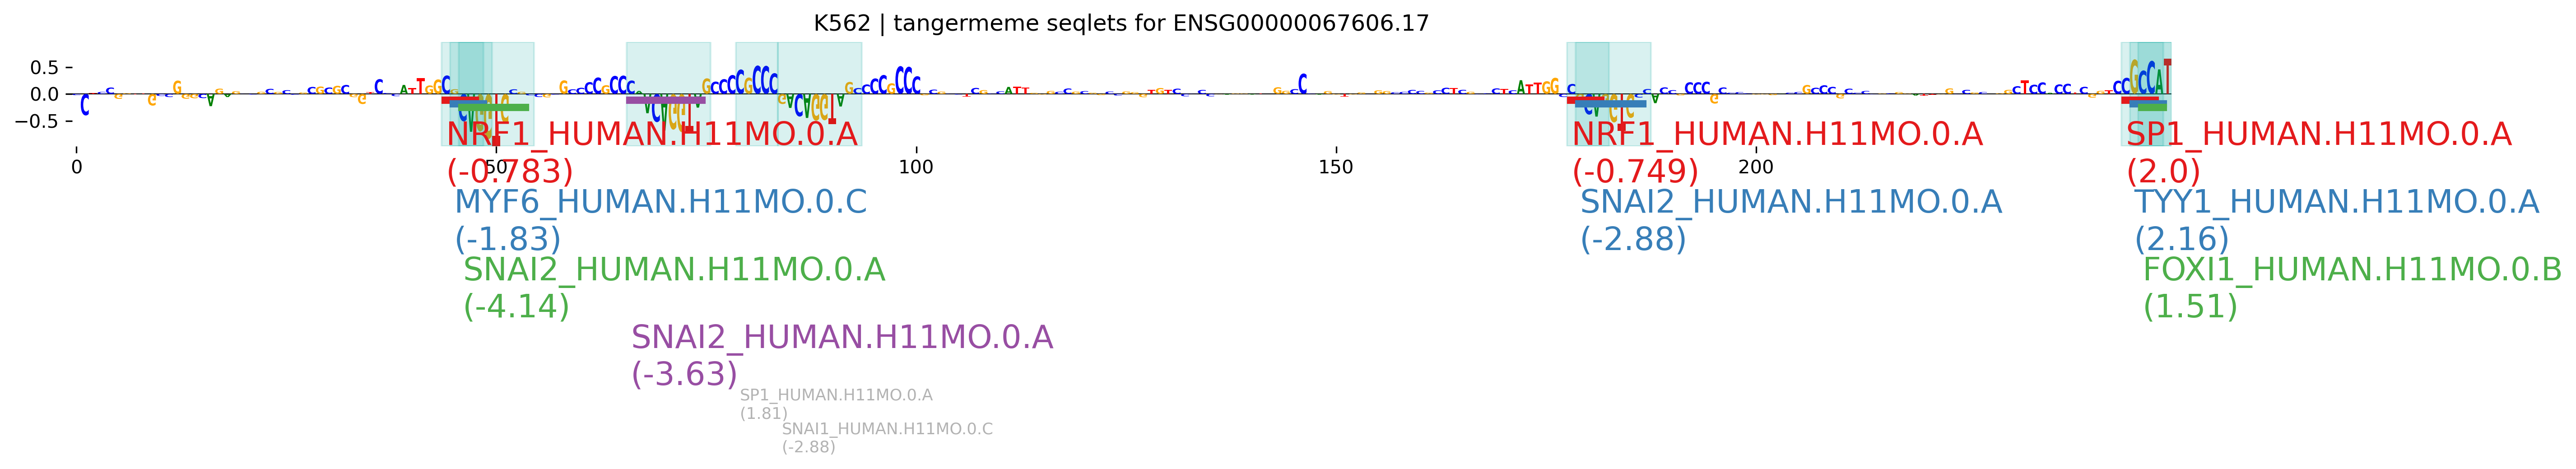

In [80]:
#HOCOMOCO v11 - threshold 0.1
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'ENSG00000067606.17',
                    k_plotLogo_dict,
                    'K562')

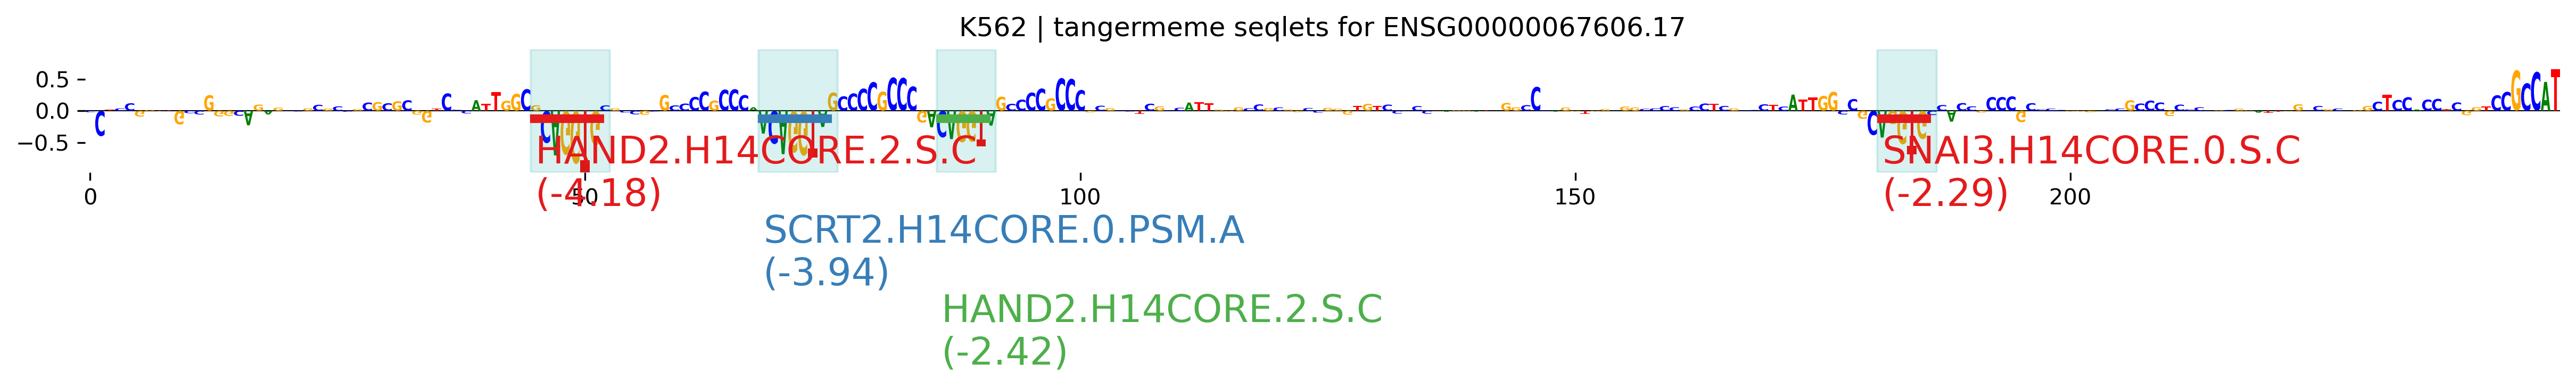

In [61]:
# HOCOMOCO v14
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'ENSG00000067606.17',
                    k_plotLogo_dict,
                    'K562')

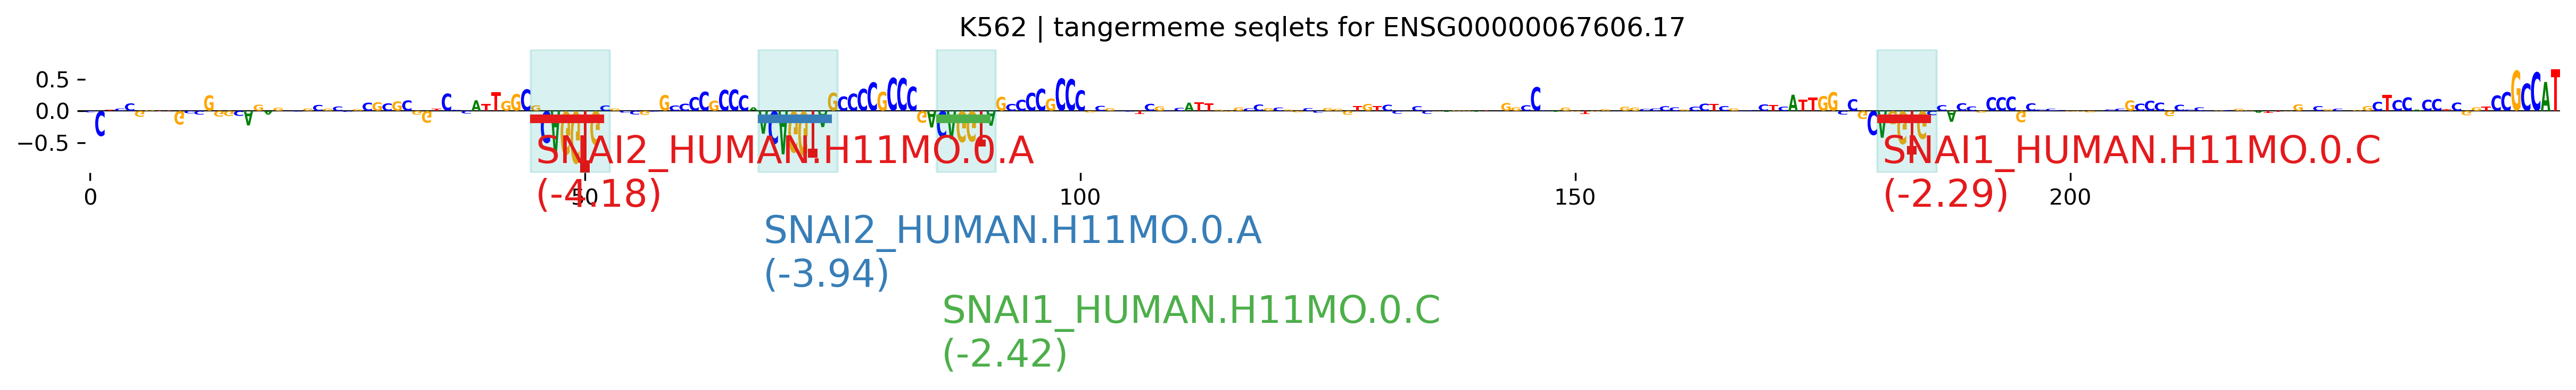

In [77]:
#JASPAR 2024 VERTEBRATE CORE
# HOCOMOCO v14
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'ENSG00000067606.17',
                    k_plotLogo_dict,
                    'K562')